In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 10000

age = np.random.randint(18, 70, n)
income = np.random.normal(50000, 15000, n).clip(15000, 100000)
tenure = np.random.randint(1, 10, n)
past_purchases = np.random.poisson(5, n)
loyalty_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.3, 0.2])
days_since_last_purchase = np.random.randint(1, 180, n)

score = (
    0.3 * loyalty_tier
    + 0.1 * past_purchases
    + np.random.normal(0, 1, n)
)

discount = np.where(score > 1.2, 20,
           np.where(score > 0.3, 10, 0))

true_effect = 20 + 10 * loyalty_tier + 0.05 * past_purchases

baseline = (
    100
    + 0.002 * income
    + 8 * past_purchases
    + 15 * loyalty_tier
    - 0.2 * days_since_last_purchase
)

noise = np.random.normal(0, 20, n)

revenue = baseline + true_effect * (discount / 20) + noise

data = pd.DataFrame({
    "age": age,
    "income": income.round(2),
    "tenure": tenure,
    "past_purchases": past_purchases,
    "loyalty_tier": loyalty_tier,
    "days_since_last_purchase": days_since_last_purchase,
    "discount": discount,
    "revenue": revenue.round(2),
    "true_effect": true_effect.round(2)
})

data.head()

,age,income,tenure,past_purchases,loyalty_tier,days_since_last_purchase,discount,revenue,true_effect
0,56,37214.20,9,4,2,116,10,247.76,40.20
1,69,57130.48,1,6,1,68,20,286.12,30.30
2,46,59486.81,2,2,1,171,0,224.77,30.10
3,32,42887.33,3,10,1,76,10,275.96,30.50
4,60,38423.42,5,5,0,138,20,199.55,20.25


In [2]:
print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (10000, 9)

Column names:
['age', 'income', 'tenure', 'past_purchases', 'loyalty_tier', 'days_since_last_purchase', 'discount', 'revenue', 'true_effect']

Missing values:
age                         0
income                      0
tenure                      0
past_purchases              0
loyalty_tier                0
days_since_last_purchase    0
discount                    0
revenue                     0
true_effect                 0
dtype: int64


In [3]:
data["discount"].value_counts().sort_index()

,count
discount,
0,3497
10,3347
20,3156


In [4]:
data.groupby("discount")["revenue"].mean()

,revenue
discount,
0,225.651979
10,246.520583
20,268.529699


In [5]:
avg_revenue = data.groupby("discount")["revenue"].mean()

naive_effect = avg_revenue[20] - avg_revenue[0]

print("Naive effect of 20% discount:", round(naive_effect, 2))

Naive effect of 20% discount: 42.88


In [6]:
data.groupby("discount")[[
    "income",
    "past_purchases",
    "loyalty_tier",
    "days_since_last_purchase"
]].mean().round(2)

,income,past_purchases,loyalty_tier,days_since_last_purchase
discount,,,,
0,50210.43,4.52,0.51,91.29
10,50070.79,5.04,0.69,90.72
20,49863.70,5.52,0.90,88.89


In [10]:
!pip install dowhy -q

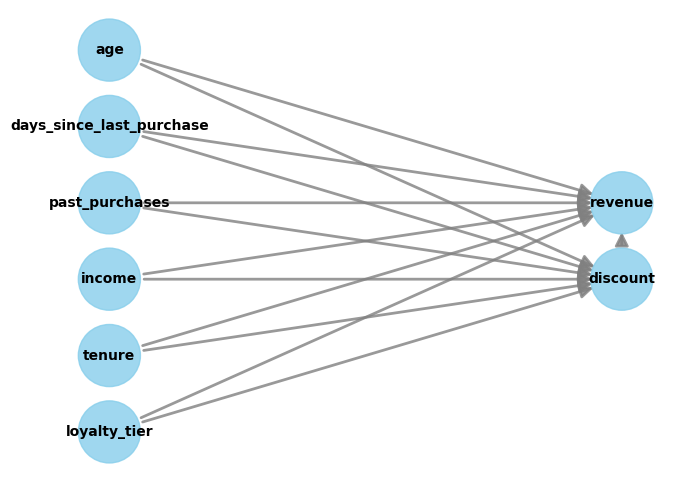

In [11]:
from dowhy import CausalModel

model = CausalModel(
    data=data,
    treatment="discount",
    outcome="revenue",
    common_causes=[
        "income",
        "past_purchases",
        "loyalty_tier",
        "days_since_last_purchase",
        "age",
        "tenure"
    ]
)

model.view_model()

In [12]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
───────────(E[revenue|loyalty_tier,tenure,income,past_purchases,days_since_las ↪
d[discount]                                                                    ↪

↪                 
↪ t_purchase,age])
↪                 
Estimand assumption 1, Unconfoundedness: If U→{discount} and U→revenue then P(revenue|discount,loyalty_tier,tenure,income,past_purchases,days_since_last_purchase,age,U) = P(revenue|discount,loyalty_tier,tenure,income,past_purchases,days_since_last_purchase,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                                         ↪
───────────(E[revenue|loyalty_tier,tenure

In [13]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print("Estimated causal effect:", round(estimate.value, 2))

Estimated causal effect: 1.35


In [14]:
data["discount_20"] = (data["discount"] == 20).astype(int)

print(data["discount_20"].value_counts())

discount_20
0    6844
1    3156
Name: count, dtype: int64


In [15]:
model_20 = CausalModel(
    data=data,
    treatment="discount_20",
    outcome="revenue",
    common_causes=[
        "income",
        "past_purchases",
        "loyalty_tier",
        "days_since_last_purchase",
        "age",
        "tenure"
    ]
)

identified_estimand_20 = model_20.identify_effect()

print(identified_estimand_20)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
─────────────(E[revenue|loyalty_tier,tenure,income,past_purchases,days_since_l ↪
d[discount₂₀]                                                                  ↪

↪                   
↪ ast_purchase,age])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{discount_20} and U→revenue then P(revenue|discount_20,loyalty_tier,tenure,income,past_purchases,days_since_last_purchase,age,U) = P(revenue|discount_20,loyalty_tier,tenure,income,past_purchases,days_since_last_purchase,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                                                        ↪
─────────────(E[revenue|lo

In [16]:
estimate_20 = model_20.estimate_effect(
    identified_estimand_20,
    method_name="backdoor.linear_regression"
)

print("Causal effect of 20% discount:", round(estimate_20.value, 2))

Causal effect of 20% discount: 20.16


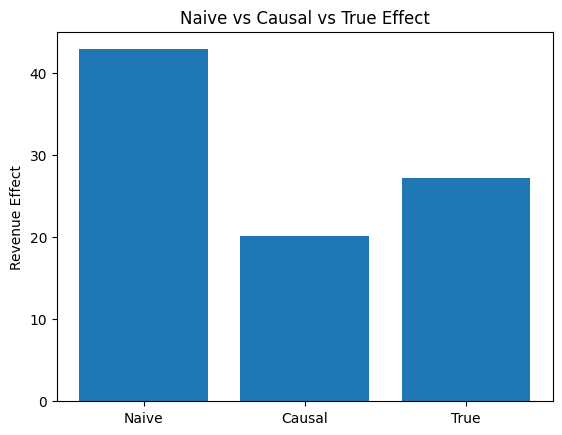

In [17]:
import matplotlib.pyplot as plt

effects = {
    "Naive": naive_effect,
    "Causal": estimate_20.value,
    "True": data["true_effect"].mean()
}

plt.bar(effects.keys(), effects.values())
plt.ylabel("Revenue Effect")
plt.title("Naive vs Causal vs True Effect")
plt.show()